# Exploratory Data Analysis: Raw Data

This notebook analyzes the raw datasets provided for the Store Sales forecasting challenge.

In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

DATA_DIR = '../data/raw'


## 1. Load Datasets

In [10]:

files = {
    'train': 'train.csv',
    'test': 'test.csv',
    'stores': 'stores.csv',
    'transactions': 'transactions.csv',
    'oil': 'oil.csv',
    'holidays': 'holidays_events.csv'
}

data = {}
for name, file in files.items():
    print(f"Loading {name}...")
    data[name] = pd.read_csv(os.path.join(DATA_DIR, file))
    if 'date' in data[name].columns:
        data[name]['date'] = pd.to_datetime(data[name]['date'])

print("All data loaded.")


Loading train...
Loading test...
Loading stores...
Loading transactions...
Loading oil...
Loading holidays...
All data loaded.


## 2. Dataset Overview
Check shapes and missing values.

In [11]:

for name, df in data.items():
    print(f"--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")
    display(df.head(3))


--- train ---
Shape: (3000888, 6)
Missing Values:
Series([], dtype: int64)



,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0


--- test ---
Shape: (28512, 5)
Missing Values:
Series([], dtype: int64)



,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2


--- stores ---
Shape: (54, 5)
Missing Values:
Series([], dtype: int64)



...

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358


--- oil ---
Shape: (1218, 2)
Missing Values:
dcoilwtico    43
dtype: int64



,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97


--- holidays ---
Shape: (350, 6)
Missing Values:
Series([], dtype: int64)



,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False


## 3. Target Variable Analysis: Sales
Analyzying the `sales` distribution and trends.

In [12]:

train = data['train']
print(f"Total Sales: {train['sales'].sum():,.0f}")


Total Sales: 1,073,644,952


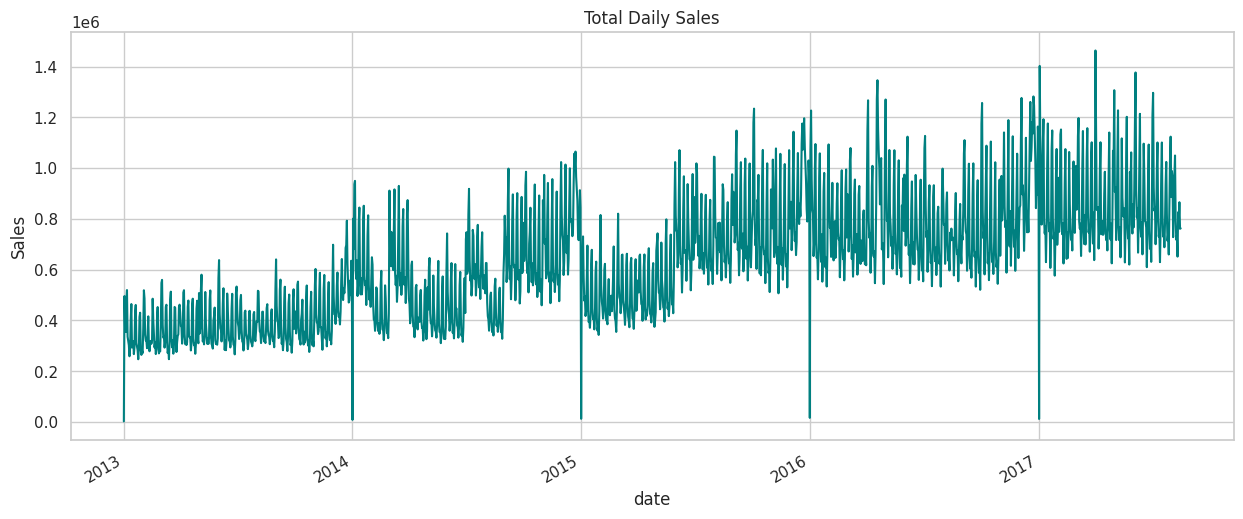

In [13]:

# Sales over time (aggregated)
daily_sales = train.groupby('date')['sales'].sum()
plt.figure()
daily_sales.plot(title='Total Daily Sales', color='teal')
plt.ylabel('Sales')
plt.show()


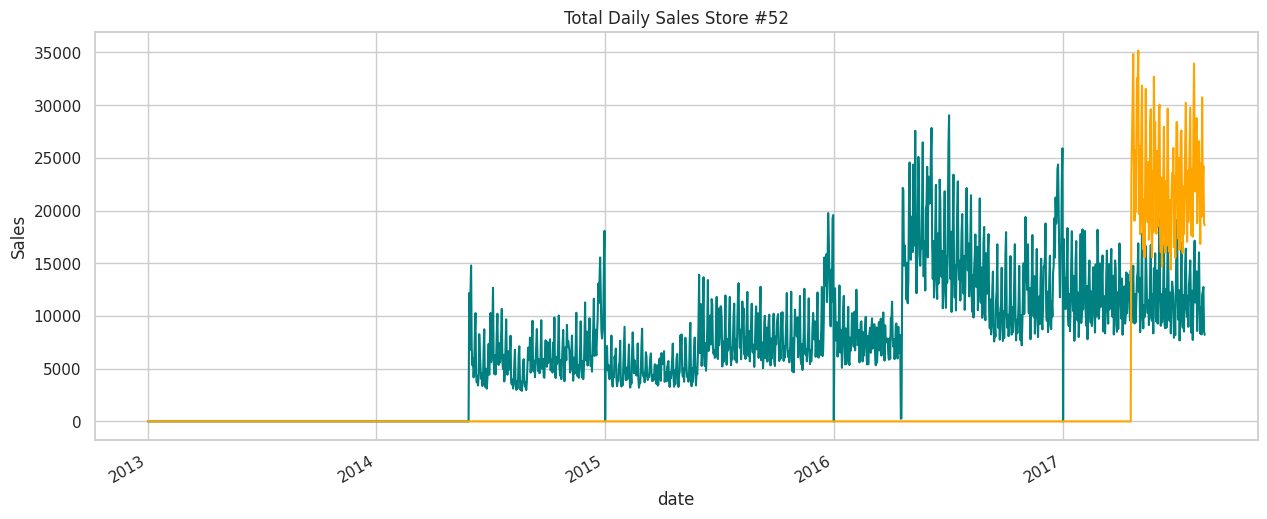

In [32]:

# Sales over time (aggregated)
daily_sales_n1 = train[train['store_nbr']==53].groupby('date')['sales'].sum()
daily_sales_n52 = train[train['store_nbr']==52].groupby('date')['sales'].sum()
plt.figure()
daily_sales_n1.plot(title='Total Daily Sales Store #1', color='teal')
daily_sales_n52.plot(title='Total Daily Sales Store #52', color='orange')
plt.ylabel('Sales')
plt.show()


In [29]:
train[train['store_nbr']==52]

,id,date,store_nbr,family,sales,onpromotion
1551,1551,2013-01-01,52,AUTOMOTIVE,0.000,0
1552,1552,2013-01-01,52,BABY CARE,0.000,0
1553,1553,2013-01-01,52,BEAUTY,0.000,0
1554,1554,2013-01-01,52,BEVERAGES,0.000,0
1555,1555,2013-01-01,52,BOOKS,0.000,0
...,...,...,...,...,...,...
3000685,3000685,2017-08-15,52,POULTRY,397.340,0
3000686,3000686,2017-08-15,52,PREPARED FOODS,104.418,0
3000687,3000687,2017-08-15,52,PRODUCE,3803.368,8
3000688,3000688,2017-08-15,52,SCHOOL AND OFFICE SUPPLIES,17.000,0


/tmp/ipykernel_16028/2534043718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=family_sales.values, y=family_sales.index, palette='viridis')


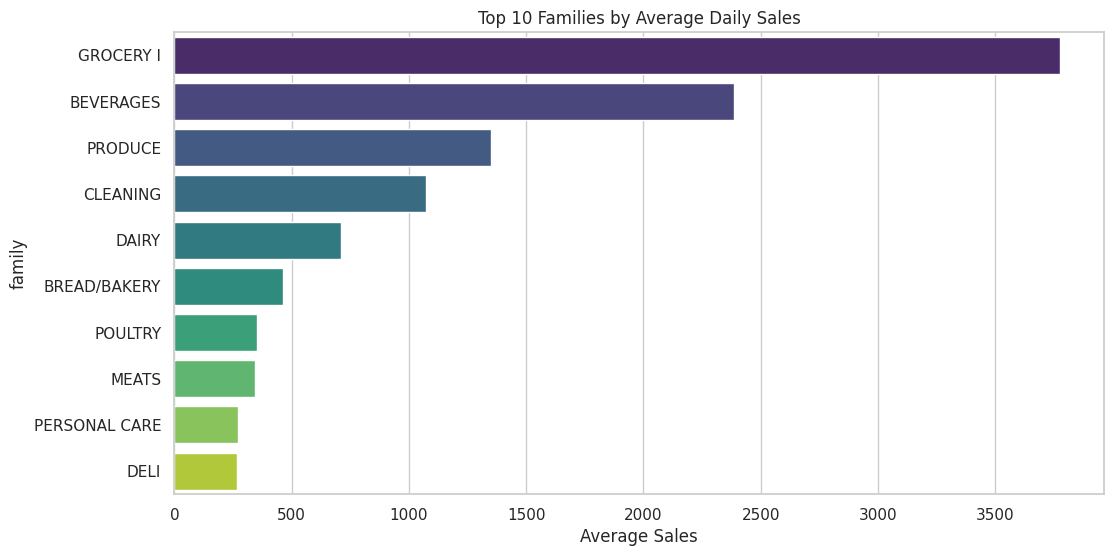

In [14]:

# Sales by Family (Top 10)
family_sales = train.groupby('family')['sales'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=family_sales.values, y=family_sales.index, palette='viridis')
plt.title('Top 10 Families by Average Daily Sales')
plt.xlabel('Average Sales')
plt.show()


## 4. Store Analysis
Analyzing sales by store metadata.

/tmp/ipykernel_16028/2446428625.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_sales.index, y=type_sales.values, palette='magma')


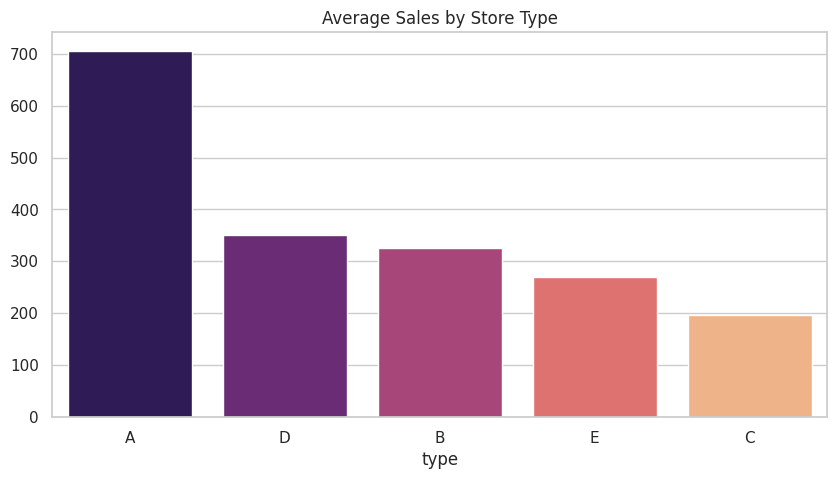

In [15]:

# Merge train with stores
train_stores = train.merge(data['stores'], on='store_nbr', how='left')

# Sales by Store Type
type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=type_sales.index, y=type_sales.values, palette='magma')
plt.title('Average Sales by Store Type')
plt.show()


## 5. Oil Prices
Analyzing the oil price trend.

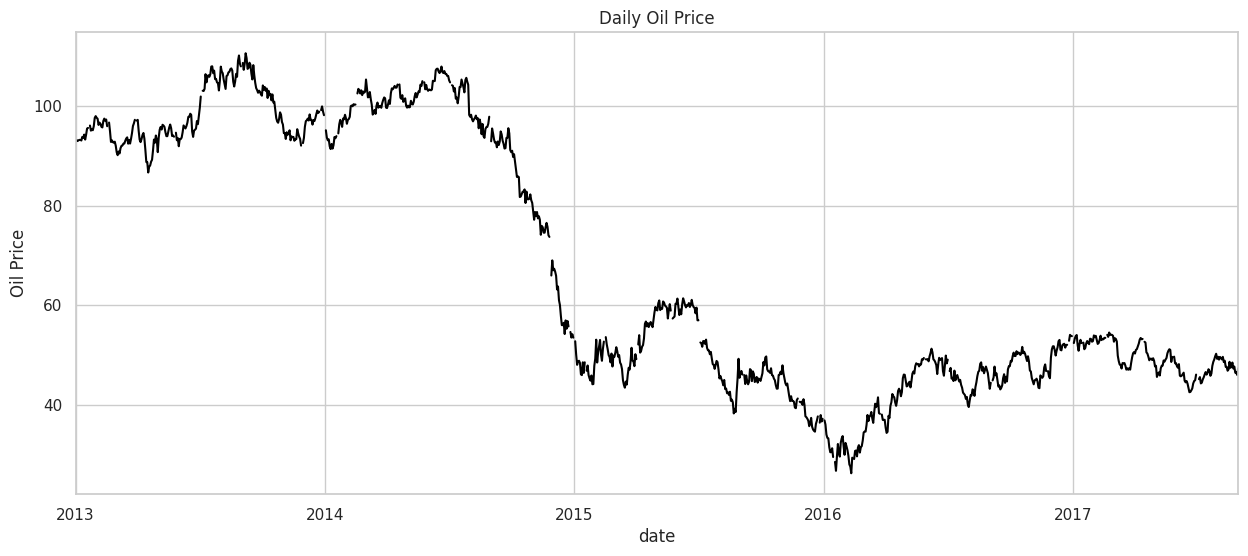

In [16]:

oil = data['oil'].set_index('date')
oil['dcoilwtico'].plot(title='Daily Oil Price', color='black')
plt.ylabel('Oil Price')
plt.show()


## 4. Transactions Analysis
Exploring volume and temporal patterns of transactions.

/tmp/ipykernel_16028/3331472699.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_trans_per_store.index, y=avg_trans_per_store.values, palette='viridis')


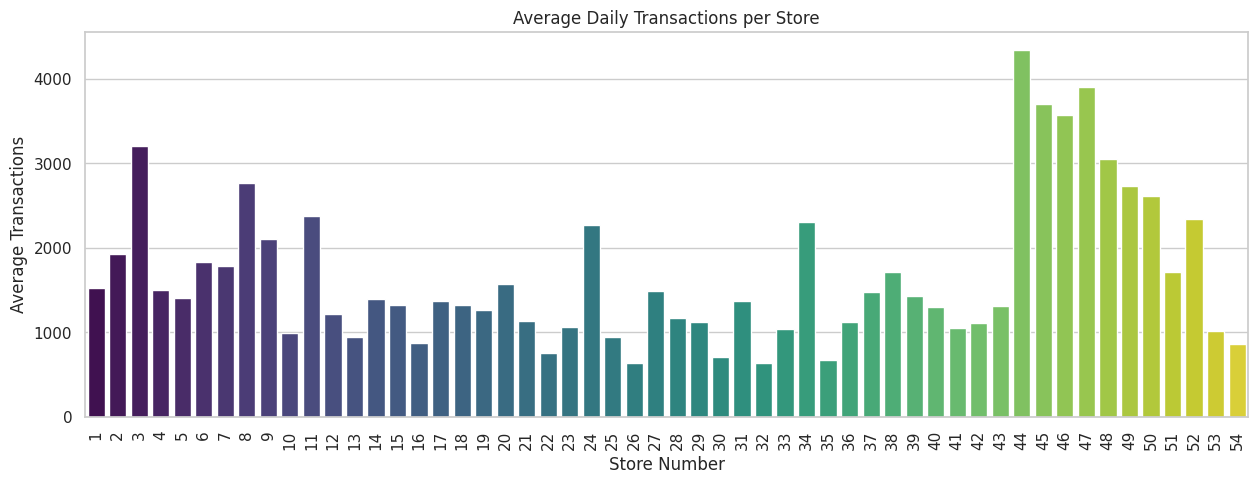

In [17]:
# 4.1 Transactions distribution for stores
trans_df = data['transactions']
avg_trans_per_store = trans_df.groupby('store_nbr')['transactions'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
sns.barplot(x=avg_trans_per_store.index, y=avg_trans_per_store.values, palette='viridis')
plt.title('Average Daily Transactions per Store')
plt.xlabel('Store Number')
plt.ylabel('Average Transactions')
plt.xticks(rotation=90)
plt.show()

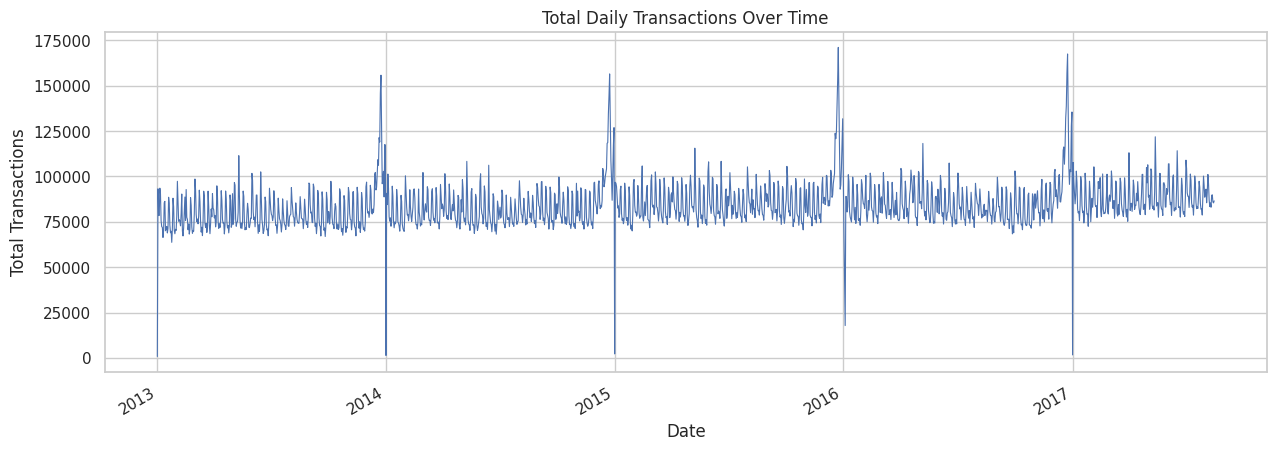

In [18]:
# 4.2 Total transactions distribution over time
daily_trans = trans_df.groupby('date')['transactions'].sum()

plt.figure(figsize=(15, 5))
daily_trans.plot(linewidth=0.8)
plt.title('Total Daily Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.show()

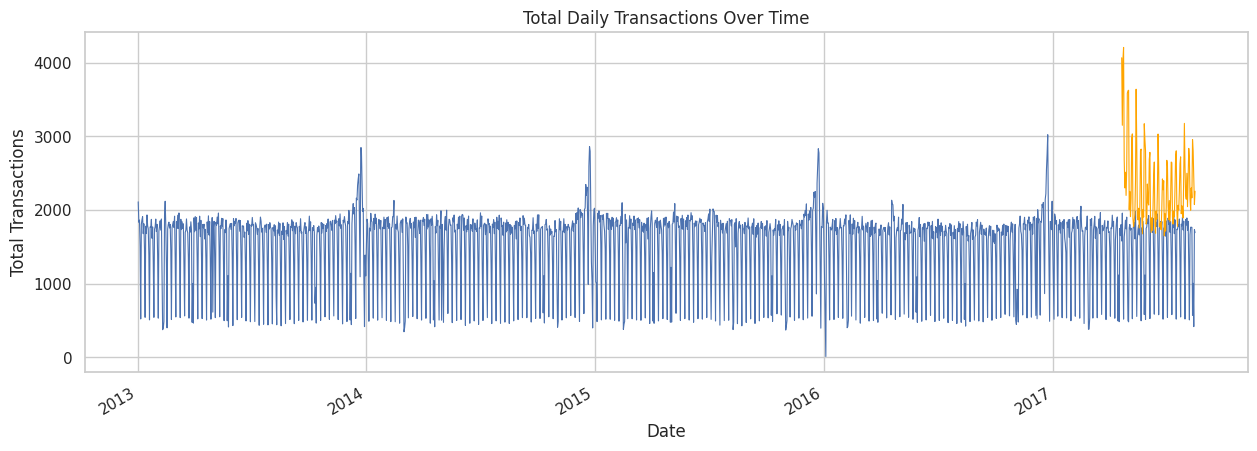

In [24]:
# 4.2 Total transactions distribution over time
daily_trans_n1 = trans_df[trans_df['store_nbr']==1].groupby('date')['transactions'].sum()
daily_trans_n52 = trans_df[trans_df['store_nbr']==52].groupby('date')['transactions'].sum()

plt.figure(figsize=(15, 5))
daily_trans_n1.plot(linewidth=0.8)
daily_trans_n52.plot(linewidth=0.8, color='orange')
plt.title('Total Daily Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.show()

In [26]:
trans_df[trans_df.store_nbr==52]

,date,store_nbr,transactions
77167,2017-04-20,52,4068
77221,2017-04-21,52,3151
77275,2017-04-22,52,4046
77329,2017-04-23,52,4209
77383,2017-04-24,52,2682
...,...,...,...
83269,2017-08-11,52,2957
83323,2017-08-12,52,2804
83377,2017-08-13,52,2433
83431,2017-08-14,52,2074


## 5. Segmented Distribution Analysis
Comparing distributions for top performing segments.

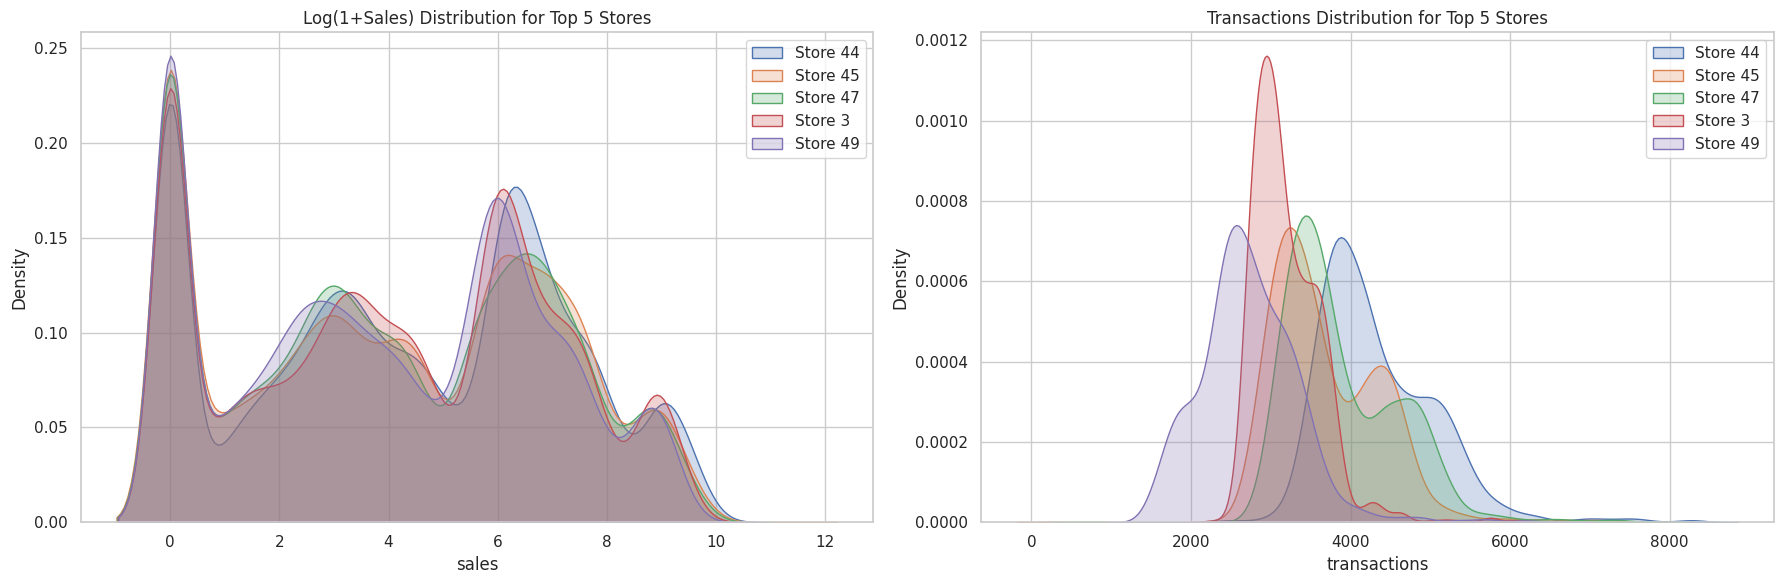

In [19]:
import numpy as np

# Identify top 5 stores and families by sales
top_5_stores = data['train'].groupby('store_nbr')['sales'].sum().nlargest(5).index.tolist()
top_5_families = data['train'].groupby('family')['sales'].sum().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sales distribution for top 5 stores (Log Scale)
for store in top_5_stores:
    subset = data['train'][data['train']['store_nbr'] == store]
    sns.kdeplot(np.log1p(subset['sales']), label=f'Store {store}', ax=axes[0], fill=True)
axes[0].set_title('Log(1+Sales) Distribution for Top 5 Stores')
axes[0].legend()

# Transactions distribution for top 5 stores
for store in top_5_stores:
    subset = data['transactions'][data['transactions']['store_nbr'] == store]
    sns.kdeplot(subset['transactions'], label=f'Store {store}', ax=axes[1], fill=True)
axes[1].set_title('Transactions Distribution for Top 5 Stores')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Store Clusters Analysis
Aggregating statistics by store cluster.

Aggregated Sales Statistics per Store Cluster:


sales                               store_nbr
            mean median      std           sum   nunique
cluster                                                 
1         326.16   15.0   825.01  5.437675e+07         3
2         260.17    5.0   732.41  2.891640e+07         2
3         194.42    6.0   582.95  7.562870e+07         7
4         296.57   19.0   725.28  4.944344e+07         3
5        1117.25   75.0  2685.28  6.208755e+07         1
6         342.66    7.0  1045.36  1.142544e+08         6
7         139.26    0.0   447.74  1.547812e+07         2
8         647.38   42.0  1595.40  1.079282e+08         3
9         274.97   16.0   655.58  3.056108e+07         2
10        255.90    5.0   731.49  8.532443e+07         6
11        603.51    5.0  1823.03  1.006143e+08         3
12        324.46   10.0   852.44  1.803097e+07         1
13        324.36   14.0   876.44  7.210225e+07         4
14        708.23   36.0  1804.02  1.574305e+08         4
15        199.01    7.0   554.88  5.529695e+07         5
16        238.60    8.0   618.12  1.325938e+07         1
17        592.23   27.0  1352.21  3.291149e+07         1

/tmp/ipykernel_16028/3863196950.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_stats.index, y=cluster_stats[('sales', 'sum')], palette='magma')


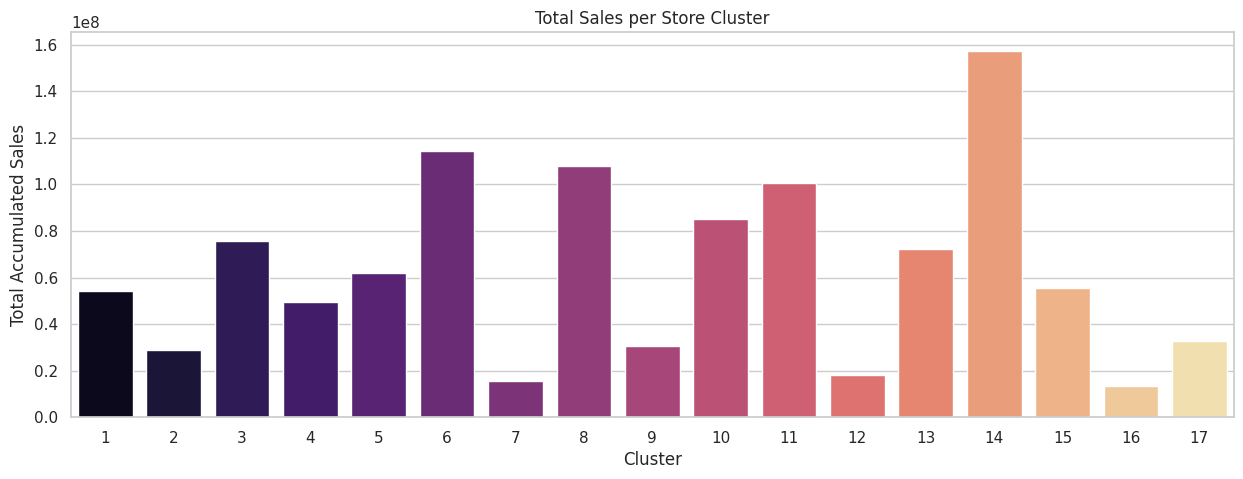

In [20]:
# Merge train with store metadata for cluster-level analysis
train_meta = data['train'].merge(data['stores'], on='store_nbr', how='left')

cluster_stats = train_meta.groupby('cluster').agg({
    'sales': ['mean', 'median', 'std', 'sum'],
    'store_nbr': 'nunique'
})

print('Aggregated Sales Statistics per Store Cluster:')
from IPython.display import display
display(cluster_stats.round(2))

# Visualizing Total Sales per Cluster
plt.figure(figsize=(15, 5))
sns.barplot(x=cluster_stats.index, y=cluster_stats[('sales', 'sum')], palette='magma')
plt.title('Total Sales per Store Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Accumulated Sales')
plt.show()

In [35]:
data['stores'][data['stores'].cluster==11]

,store_nbr,city,state,type,cluster
44,45,Quito,Pichincha,A,11
48,49,Quito,Pichincha,A,11
51,52,Manta,Manabi,A,11


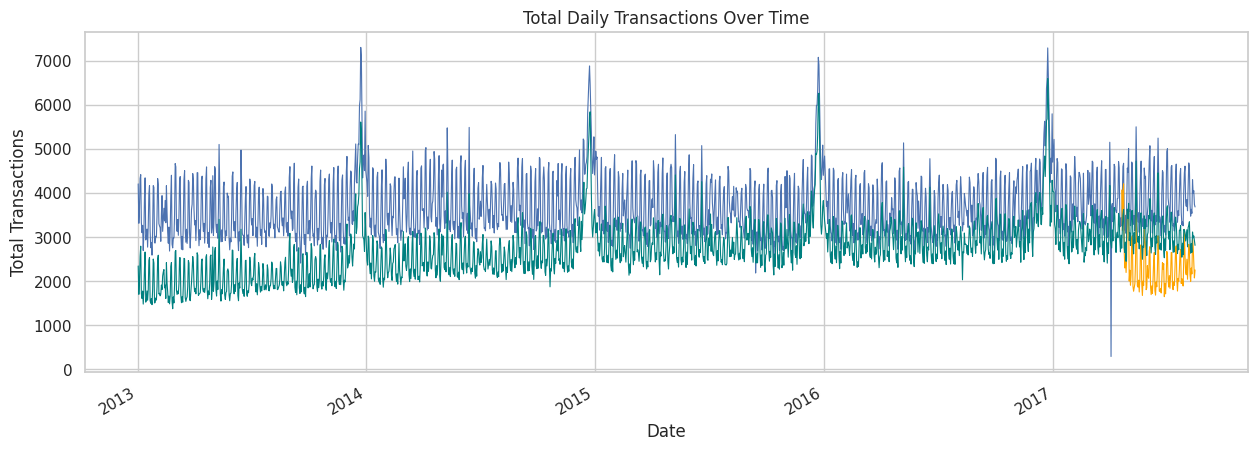

In [36]:
# 4.2 Total transactions distribution over time
daily_trans_n45 = trans_df[trans_df['store_nbr']==45].groupby('date')['transactions'].sum()
daily_trans_n49 = trans_df[trans_df['store_nbr']==49].groupby('date')['transactions'].sum()
daily_trans_n52 = trans_df[trans_df['store_nbr']==52].groupby('date')['transactions'].sum()


plt.figure(figsize=(15, 5))
daily_trans_n45.plot(linewidth=0.8)
daily_trans_n52.plot(linewidth=0.8, color='orange')
daily_trans_n49.plot(linewidth=0.8, color='teal')
plt.title('Total Daily Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.show()

In [46]:
trans_df.groupby('store_nbr').agg({'date':[min, max,len]})

date                 
                 min        max   len
store_nbr                            
1         2013-01-02 2017-08-15  1676
2         2013-01-02 2017-08-15  1677
3         2013-01-02 2017-08-15  1676
4         2013-01-02 2017-08-15  1676
5         2013-01-02 2017-08-15  1677
6         2013-01-02 2017-08-15  1676
7         2013-01-02 2017-08-15  1675
8         2013-01-02 2017-08-15  1676
9         2013-01-02 2017-08-15  1676
10        2013-01-02 2017-08-15  1675
11        2013-01-02 2017-08-15  1676
12        2013-01-02 2017-08-15  1616
13        2013-01-02 2017-08-15  1676
14        2013-01-02 2017-08-15  1638
15        2013-01-02 2017-08-15  1676
16        2013-01-02 2017-08-15  1677
17        2013-01-02 2017-08-15  1674
18        2013-01-02 2017-08-15  1566
19        2013-01-02 2017-08-15  1676
20        2015-02-13 2017-08-15   909
21        2015-07-24 2017-08-15   748
22        2015-10-09 2017-08-15   671
23        2013-01-02 2017-08-15  1677
24        2013-01-02 2017-08-15  1577
25        2013-01-01 2017-08-15  1615
26        2013-01-02 2017-08-15  1678
27        2013-01-02 2017-08-15  1677
28        2013-01-02 2017-08-15  1677
29        2015-03-20 2017-08-15   874
30        2013-01-02 2017-08-15  1655
31        2013-01-02 2017-08-15  1678
32        2013-01-02 2017-08-15  1677
33        2013-01-02 2017-08-15  1678
34        2013-01-02 2017-08-15  1678
35        2013-01-02 2017-08-15  1676
36        2013-05-09 2017-08-15  1551
37        2013-01-02 2017-08-15  1678
38        2013-01-02 2017-08-15  1678
39        2013-01-02 2017-08-15  1678
40        2013-01-02 2017-08-15  1677
41        2013-01-02 2017-08-15  1677
42        2015-08-21 2017-08-15   720
43        2013-01-02 2017-08-15  1672
44        2013-01-02 2017-08-15  1677
45        2013-01-02 2017-08-15  1677
46        2013-01-02 2017-08-15  1677
47        2013-01-02 2017-08-15  1677
48        2013-01-02 2017-08-15  1677
49        2013-01-02 2017-08-15  1677
50        2013-01-02 2017-08-15  1677
51        2013-01-02 2017-08-15  1677
52        2017-04-20 2017-08-15   118
53        2014-05-29 2017-08-15  1167
54        2013-01-02 2017-08-15  1676

In [ ]:
# 4.2 Total transactions distribution over time
daily_trans_n45 = trans_df[trans_df['store_nbr']==45].groupby('date')['transactions'].sum()
daily_trans_n49 = trans_df[trans_df['store_nbr']==49].groupby('date')['transactions'].sum()
daily_trans_n52 = trans_df[trans_df['store_nbr']==52].groupby('date')['transactions'].sum()


plt.figure(figsize=(15, 5))
daily_trans_n45.plot(linewidth=0.8)
daily_trans_n52.plot(linewidth=0.8, color='orange')
daily_trans_n49.plot(linewidth=0.8, color='teal')
plt.title('Total Daily Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.show()